# Lightcast-Causal — Identifying Causal Drivers of Nursing Shortages (Michigan counties)

**Goal.** Inform policy with *credibly causal* estimates of what drives county nurse shortages, where shortage pressure is proxied by **Lightcast job postings per 10k** (`rn_postings_per_10k`, `lpn_postings_per_10k`) and, complementarily, by **licensed supply** (`rn_per_100k`, `lpn_per_100k`).

**Honest stance.** This is observational county-year panel data. Causal identification is *limited*; we organize models as a **ladder of identification credibility** and state exactly what each can and cannot support. We do **not** dress up associations as causal effects.

| # | Model | Identifying variation | Causal credibility |
|---|---|---|---|
| M0 | Descriptive TWFE | within-county, net of year shocks | **None** (association) |
| M1 | Predetermined-lag TWFE | lagged (pre-dated) regressors | **Weak** (sequential exogeneity) |
| (M2) | Wage IV — *not pursued* | no valid instrument exists | **wage excluded** from all models |
| M3 | Training-pipeline reduced form | predetermined IPEDS completions | **Suggestive** (policy-actionable) |

All panel models use county + year fixed effects with SEs clustered by county.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch
from matplotlib.lines import Line2D
from linearmodels.panel import PanelOLS
from linearmodels.iv import IV2SLS

from pathlib import Path
# --- locate the repo root from ANY launch directory ---
def _find_repo_root():
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / 'final-regressions-data.csv').exists():
            return d
    fb = Path('/Users/juanvilla/Documents/gse-580-clean')  # absolute fallback
    if (fb / 'final-regressions-data.csv').exists():
        return fb
    raise FileNotFoundError('Could not find final-regressions-data.csv. '
                            'Set ROOT manually to your project folder. Searched from: ' + str(here))
ROOT = _find_repo_root()
os.chdir(ROOT)
print('working dir set to repo root:', ROOT)
os.makedirs('outputs', exist_ok=True); os.makedirs('figures', exist_ok=True)
pd.set_option('display.width', 220, 'display.max_columns', 30,
              'display.float_format', lambda x: f'{x:,.3f}')

df = pd.read_csv('final-regressions-data.csv', low_memory=False, dtype={'fips': str})
df['fips'] = df['fips'].str.zfill(5)
df = df.sort_values(['fips', 'year']).reset_index(drop=True)

# --- calendar-aware lags (insert explicit 2018 gap, then shift) ---
LAG_SRC = ['rn_per_100k','lpn_per_100k','rn_pums_wage','lpn_pums_wage',
           'rn_age_55plus_pct','lpn_age_55plus_pct','rn_postings_per_10k','lpn_postings_per_10k']
full = pd.MultiIndex.from_product(
    [df['fips'].unique(), range(int(df.year.min()), int(df.year.max())+1)], names=['fips','year'])
grid = df.set_index(['fips','year'])[LAG_SRC].reindex(full)
lags = pd.DataFrame(index=full)
for c in LAG_SRC:
    lags[f'{c}_lag1'] = grid.groupby('fips')[c].shift(1)
df = df.merge(lags.reset_index(), on=['fips','year'], how='left')
print('panel:', df.shape, '| years', int(df.year.min()), '-', int(df.year.max()))

DEMAND = ['share_65plus','hosp_beds_per_1k','nh_beds_per_65plus_ahrf','poverty_rate','bachelors_plus_share']

def twfe(y, xs, label):
    xs = list(dict.fromkeys(xs))
    d = df.dropna(subset=[y]+xs).set_index(['fips','year'])
    res = PanelOLS(d[y], d[xs], entity_effects=True, time_effects=True,
                   drop_absorbed=True, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
    print(f'\n=== {label} ===  N={int(res.nobs)} counties={res.entity_info.total} within_R2={res.rsquared:.3f}')
    print(pd.DataFrame({'coef':res.params,'se':res.std_errors,'p':res.pvalues}).round(3).to_string())
    return res

def stars(p): return '' if p!=p else '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
print('helpers ready')

working dir set to repo root: /Users/juanvilla/Documents/gse-580-clean
panel: (1162, 154) | years 2010 - 2023
helpers ready


## Causal pathways — master DAG

The structural picture we are trying to identify. **Wage** and **training pipeline** are the policy-relevant causes of supply; supply and **demand (aging/beds)** jointly determine **shortage (postings)**. An unobserved **local economy** confounds wage, supply, and shortage. The **Bartik instrument** is meant to break that confounding by moving wages exogenously — but see M2 for why it fails under fixed effects.

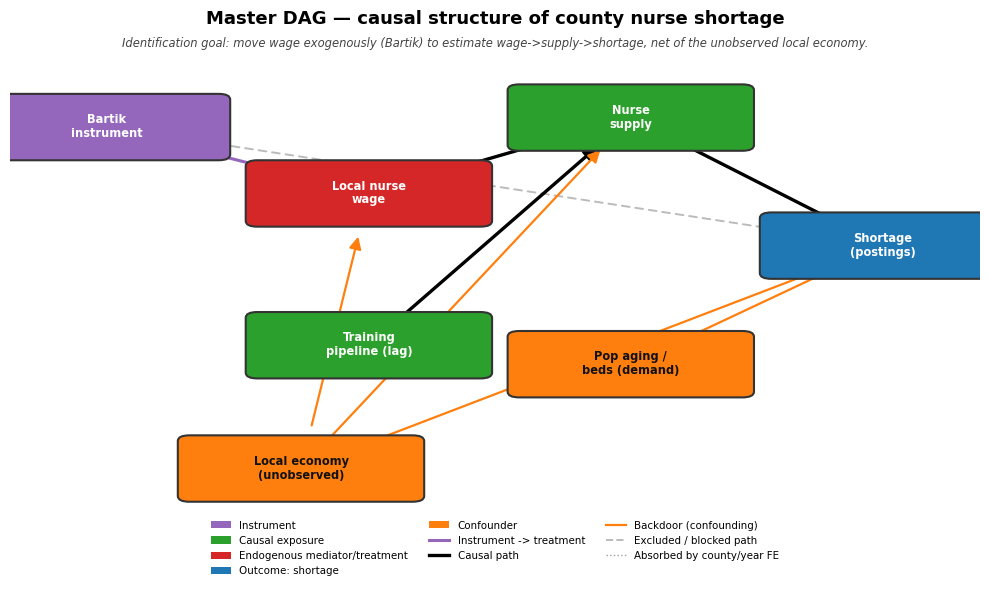

In [3]:
ROLE = {'exposure':'#2ca02c','outcome':'#1f77b4','confounder':'#ff7f0e',
        'mediator':'#d62728','instrument':'#9467bd','control':'#9e9e9e','fe':'#ffffff'}
EDGE = {'causal':dict(color='#000',lw=2.4),'backdoor':dict(color='#ff7f0e',lw=1.6),
        'mediated':dict(color='#d62728',lw=2.0),'iv':dict(color='#9467bd',lw=2.2),
        'blocked':dict(color='#bbbbbb',lw=1.4,ls=(0,(4,3))),'fe':dict(color='#9e9e9e',lw=1.0,ls=':')}

def draw_dag(nodes, edges, title, outpath, note=''):
    fig, ax = plt.subplots(figsize=(10, 6))
    for a,b,et in edges:
        (xa,ya,_),(xb,yb,_)=nodes[a],nodes[b]
        ax.add_patch(FancyArrowPatch((xa,ya),(xb,yb),arrowstyle='-|>',mutation_scale=18,
                     shrinkA=32,shrinkB=32,zorder=1,**EDGE[et]))
    for nm,(x,y,role) in nodes.items():
        tc='white' if role in ('exposure','outcome','mediator','instrument') else '#111'
        ax.add_patch(FancyBboxPatch((x-0.115,y-0.058),0.23,0.116,boxstyle='round,pad=0.012',
                     linewidth=1.5,edgecolor='#333',facecolor=ROLE[role],
                     linestyle='--' if role=='fe' else '-',zorder=2))
        ax.text(x,y,nm,ha='center',va='center',fontsize=8.2,color=tc,fontweight='bold',zorder=3)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.set_title(title,fontsize=13,fontweight='bold')
    if note: ax.text(0.5,0.99,note,ha='center',va='top',fontsize=8.3,style='italic',color='#444',transform=ax.transAxes)
    leg=[Patch(facecolor=ROLE['instrument'],label='Instrument'),
         Patch(facecolor=ROLE['exposure'],label='Causal exposure'),
         Patch(facecolor=ROLE['mediator'],label='Endogenous mediator/treatment'),
         Patch(facecolor=ROLE['outcome'],label='Outcome: shortage'),
         Patch(facecolor=ROLE['confounder'],label='Confounder'),
         Line2D([0],[0],color='#9467bd',lw=2.2,label='Instrument -> treatment'),
         Line2D([0],[0],color='#000',lw=2.4,label='Causal path'),
         Line2D([0],[0],color='#ff7f0e',lw=1.6,label='Backdoor (confounding)'),
         Line2D([0],[0],color='#bbbbbb',lw=1.4,ls='--',label='Excluded / blocked path'),
         Line2D([0],[0],color='#9e9e9e',lw=1.0,ls=':',label='Absorbed by county/year FE')]
    ax.legend(handles=leg,loc='upper center',bbox_to_anchor=(0.5,-0.01),ncol=3,fontsize=7.4,frameon=False)
    plt.tight_layout(); plt.savefig(outpath,dpi=160,bbox_inches='tight',facecolor='white'); plt.show()

draw_dag(
 {'Bartik\ninstrument':(0.10,0.80,'instrument'),
  'Local nurse\nwage':(0.37,0.66,'mediator'),
  'Nurse\nsupply':(0.64,0.82,'exposure'),
  'Shortage\n(postings)':(0.90,0.55,'outcome'),
  'Training\npipeline (lag)':(0.37,0.34,'exposure'),
  'Pop aging /\nbeds (demand)':(0.64,0.30,'confounder'),
  'Local economy\n(unobserved)':(0.30,0.08,'confounder')},
 [('Bartik\ninstrument','Local nurse\nwage','iv'),
  ('Bartik\ninstrument','Shortage\n(postings)','blocked'),
  ('Local nurse\nwage','Nurse\nsupply','causal'),
  ('Nurse\nsupply','Shortage\n(postings)','causal'),
  ('Training\npipeline (lag)','Nurse\nsupply','causal'),
  ('Pop aging /\nbeds (demand)','Shortage\n(postings)','backdoor'),
  ('Local economy\n(unobserved)','Local nurse\nwage','backdoor'),
  ('Local economy\n(unobserved)','Nurse\nsupply','backdoor'),
  ('Local economy\n(unobserved)','Shortage\n(postings)','backdoor')],
 'Master DAG — causal structure of county nurse shortage',
 'figures/causal_dag_master.png',
 note='Identification goal: move wage exogenously (Bartik) to estimate wage->supply->shortage, net of the unobserved local economy.')

## M0 — Descriptive TWFE (benchmark; **association, not causal**)

Conditional within-county correlations of shortage with structural factors, net of statewide year shocks. This is the honest baseline: it tells us *where* shortage co-moves with factors, not *why*.

In [4]:
m0 = {}
for o in ['rn','lpn']:
    y=f'{o}_postings_per_10k'
    m0[o]=twfe(y, DEMAND+[f'{o}_per_100k_lag1'], f'M0 Descriptive — {o.upper()} postings')


=== M0 Descriptive — RN postings ===  N=828 counties=83.0 within_R2=0.034
                          coef    se     p
share_65plus            -0.789 1.784 0.658
hosp_beds_per_1k         1.488 1.095 0.175
nh_beds_per_65plus_ahrf -0.771 0.126 0.000
poverty_rate             1.356 0.662 0.041
bachelors_plus_share     0.077 0.620 0.901
rn_per_100k_lag1        -0.012 0.008 0.157

=== M0 Descriptive — LPN postings ===  N=826 counties=83.0 within_R2=0.021
                          coef    se     p
share_65plus            -0.636 0.459 0.166
hosp_beds_per_1k         0.270 0.209 0.197
nh_beds_per_65plus_ahrf -0.202 0.040 0.000
poverty_rate             0.217 0.262 0.407
bachelors_plus_share     0.176 0.251 0.483
lpn_per_100k_lag1       -0.003 0.006 0.650


## M1 — Predetermined-lag TWFE (**weak causal: sequential exogeneity**)

Every right-hand-side factor is **lagged one year**, so it is pre-dated relative to the outcome: today's shortage cannot mechanically cause last year's supply, wages, or workforce age. This rules out *contemporaneous reverse causation* but not persistent unobserved confounding or dynamic feedback. Interpret as "predetermined predictors of later shortage.

In [5]:
m1={}
for o in ['rn','lpn']:
    y=f'{o}_postings_per_10k'
    xs=DEMAND+[f'{o}_per_100k_lag1', f'ipeds_{o}_per_10k_lag1',
              f'{o}_age_55plus_pct_lag1']   # wage excluded: no valid instrument
    m1[o]=twfe(y, xs, f'M1 Predetermined — {o.upper()} postings')


=== M1 Predetermined — RN postings ===  N=745 counties=83.0 within_R2=0.021
                          coef    se     p
share_65plus            -0.346 0.982 0.725
hosp_beds_per_1k         0.833 0.752 0.268
nh_beds_per_65plus_ahrf -0.529 0.125 0.000
poverty_rate             1.447 0.664 0.030
bachelors_plus_share     0.641 0.724 0.376
rn_per_100k_lag1        -0.007 0.008 0.348
ipeds_rn_per_10k_lag1    0.065 0.148 0.659
rn_age_55plus_pct_lag1   0.134 0.307 0.662

=== M1 Predetermined — LPN postings ===  N=744 counties=83.0 within_R2=0.024
                          coef    se     p
share_65plus            -0.346 0.398 0.385
hosp_beds_per_1k         0.138 0.177 0.437
nh_beds_per_65plus_ahrf -0.146 0.045 0.001
poverty_rate             0.310 0.284 0.276
bachelors_plus_share     0.308 0.261 0.239
lpn_per_100k_lag1       -0.003 0.007 0.631
ipeds_lpn_per_10k_lag1   0.028 0.067 0.673
lpn_age_55plus_pct_lag1  0.039 0.024 0.106


> **Note (read first).** Sections M2–M2c are retained only to *justify a modeling decision*: having found no valid wage instrument, **we exclude nurse wages from every model**. They are not headline results. See **"Limitation: the omitted wage channel"** below for the consequence.

## M2 — Bartik shift-share IV (relevance now solved; **exclusion fails**)

We test two instruments for the **local nurse wage**, using the better-measured **OEWS** administrative wage (`rn_a_mean`) as the endogenous variable:
- `bartik_iv` — the original *single-shock* shift-share (base-year health share × one national RN-wage trend);
- `bartik_alt` — a *multi-subsector* shift-share built from base-year county shares in ambulatory (621), hospitals (622), and nursing/residential (623) care, each interacted with **that subsector's** national employment growth (its three components `bartik_alt_amb/hosp/nh` are valid separate instruments).

We check instrument **strength (relevance)** across designs first, then run the one credible specification.

In [6]:
# Compare the single-shock vs multi-subsector instrument, endogenous = OEWS wage.
ctrl=DEMAND; ENDOG='rn_a_mean'
ALT3=['bartik_alt_amb','bartik_alt_hosp','bartik_alt_nh']
def fsF(instr, design):
    d=df.dropna(subset=['rn_per_100k',ENDOG]+instr+ctrl).copy()
    fe={'pooled':'','county FE':' + C(fips)','year FE':' + C(year)','county+year FE':' + C(fips) + C(year)'}[design]
    f=f"rn_per_100k ~ 1 + {' + '.join(ctrl)}{fe} + [{ENDOG} ~ {' + '.join(instr)}]"
    r=IV2SLS.from_formula(f,d).fit(cov_type='clustered',clusters=d['fips'])
    return r.first_stage.diagnostics.loc[ENDOG,'f.stat'], int(r.nobs)

print('First-stage F (relevance; target F>10) with endogenous = OEWS rn_a_mean:')
print(f"  {'design':<16}{'OLD bartik_iv':>15}{'NEW bartik_alt (3-subsector)':>32}")
for des in ['pooled','county FE','year FE','county+year FE']:
    fo,_=fsF(['bartik_iv'],des); fn,N=fsF(ALT3,des)
    print(f"  {des:<16}{fo:>15.2f}{fn:>32.2f}   N={N}")
print('\n-> Multi-subsector + OEWS is STRONG under county FE (F~37) but STILL absorbed under')
print('   two-way FE: the shocks are national (common), so year FE soaks them up.')

# Credible spec: county FE + 3-subsector Bartik. Estimate wage effect on supply and shortage.
print('\nCredible 2SLS (county FE; OEWS wage instrumented by the 3-subsector Bartik):')
for outc in ['rn_per_100k','rn_postings_per_10k']:
    d=df.dropna(subset=[outc,ENDOG]+ALT3+ctrl).copy()
    f=f"{outc} ~ 1 + {' + '.join(ctrl)} + C(fips) + [{ENDOG} ~ {' + '.join(ALT3)}]"
    r=IV2SLS.from_formula(f,d).fit(cov_type='clustered',clusters=d['fips'])
    F=r.first_stage.diagnostics.loc[ENDOG,'f.stat']
    b,se,pv=r.params[ENDOG],r.std_errors[ENDOG],r.pvalues[ENDOG]
    print(f"  wage -> {outc:<20} coef={b:+.4f}  se={se:.4f}  p={pv:.3f}   (F={F:.1f}, N={int(r.nobs)})")

First-stage F (relevance; target F>10) with endogenous = OEWS rn_a_mean:
  design            OLD bartik_iv    NEW bartik_alt (3-subsector)
  pooled                    10.59                           10.60   N=547
  county FE                 32.01                           36.65   N=547
  year FE                    1.09                            5.73   N=547
  county+year FE             0.01                            0.09   N=547

-> Multi-subsector + OEWS is STRONG under county FE (F~37) but STILL absorbed under
   two-way FE: the shocks are national (common), so year FE soaks them up.

Credible 2SLS (county FE; OEWS wage instrumented by the 3-subsector Bartik):
  wage -> rn_per_100k          coef=-0.0066  se=0.0069  p=0.343   (F=36.6, N=547)
  wage -> rn_postings_per_10k  coef=+0.0028  se=0.0009  p=0.001   (F=38.1, N=605)


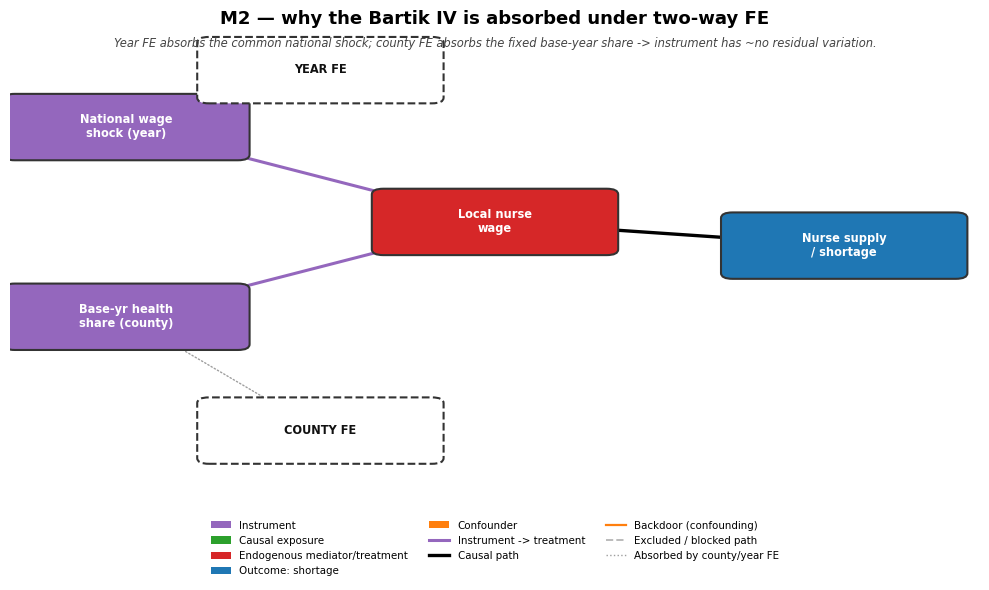

In [7]:
# Why it fails, as a DAG: FE absorb both shift-share components.
draw_dag(
 {'National wage\nshock (year)':(0.12,0.80,'instrument'),
  'Base-yr health\nshare (county)':(0.12,0.40,'instrument'),
  'Local nurse\nwage':(0.50,0.60,'mediator'),
  'Nurse supply\n/ shortage':(0.86,0.55,'outcome'),
  'YEAR FE':(0.32,0.92,'fe'),
  'COUNTY FE':(0.32,0.16,'fe')},
 [('National wage\nshock (year)','Local nurse\nwage','iv'),
  ('Base-yr health\nshare (county)','Local nurse\nwage','iv'),
  ('Local nurse\nwage','Nurse supply\n/ shortage','causal'),
  ('YEAR FE','National wage\nshock (year)','fe'),
  ('COUNTY FE','Base-yr health\nshare (county)','fe')],
 'M2 — why the Bartik IV is absorbed under two-way FE',
 'figures/causal_dag_bartik_fail.png',
 note='Year FE absorbs the common national shock; county FE absorbs the fixed base-year share -> instrument has ~no residual variation.')

### The new problem: `bartik_alt` is strong but **not valid** for a wage effect

The multi-subsector instrument fixes *relevance* (F~37 under county FE) but it is a **labor-demand** shifter. A health-demand shock raises local nurse **wages** *and* drives **postings** directly through demand. That second path — `bartik_alt -> health demand -> postings` — **violates the exclusion restriction** for estimating the effect of *wages* on supply/shortage.

Empirically this shows up as a **significant, positive wage -> postings** 2SLS coefficient (the demand channel) and an insignificant wage -> supply coefficient. The strong first stage does **not** rescue the causal claim: a demand instrument cannot identify a labor-supply response. And under two-way FE the instrument is absorbed entirely. **Net: relevance solved, exclusion not — no causal wage->supply estimate is supported.**

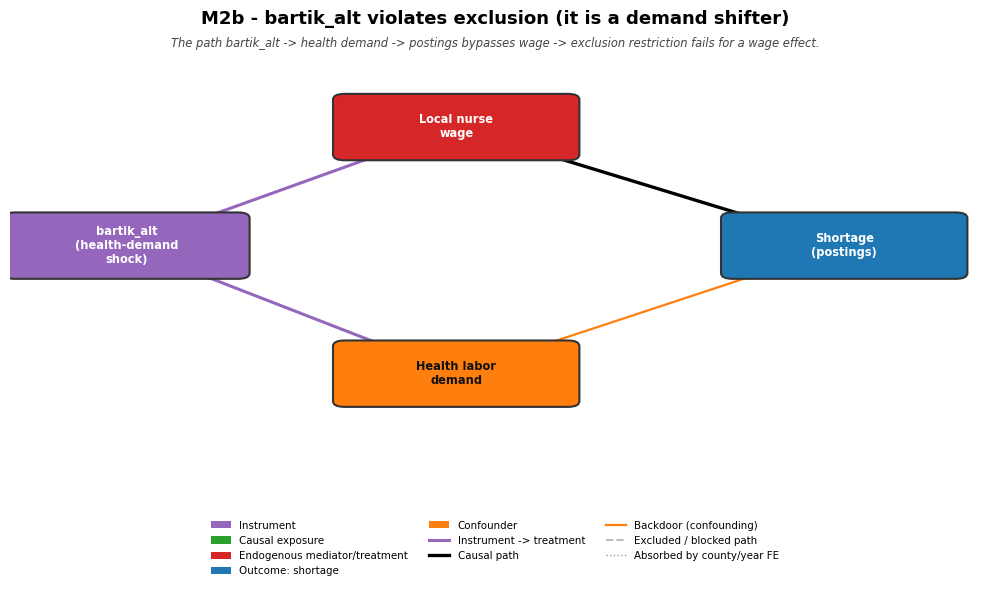

In [8]:
draw_dag(
 {'bartik_alt\n(health-demand\nshock)':(0.12,0.55,'instrument'),
  'Local nurse\nwage':(0.46,0.80,'mediator'),
  'Health labor\ndemand':(0.46,0.28,'confounder'),
  'Shortage\n(postings)':(0.86,0.55,'outcome')},
 [('bartik_alt\n(health-demand\nshock)','Local nurse\nwage','iv'),
  ('Local nurse\nwage','Shortage\n(postings)','causal'),
  ('bartik_alt\n(health-demand\nshock)','Health labor\ndemand','iv'),
  ('Health labor\ndemand','Shortage\n(postings)','backdoor')],
 'M2b - bartik_alt violates exclusion (it is a demand shifter)',
 'figures/causal_dag_bartik_alt_exclusion.png',
 note='The path bartik_alt -> health demand -> postings bypasses wage -> exclusion restriction fails for a wage effect.')

## M2c — Outside-option Bartik as a labor-**supply** shifter (`bartik_supply`)

The demand-side Bartik (`bartik_alt`) was strong but exclusion-invalid. We try the mirror image: a shift-share built from base-year county shares in the **18 non-health 2-digit NAICS sectors**, each × its national employment growth. When outside jobs boom, fewer people supply nursing labor → it shifts the nurse labor-**supply** curve. A supply shifter is the textbook way to trace out **labor demand**, so we use employment (`rn_tot_emp`) as the cleaner quantity (vs the residence-based licensed stock).

In [14]:
SUP='bartik_supply'; ENDOG='rn_a_mean'
def iv_fit(outc, instr, design):
    d=df.dropna(subset=[outc,ENDOG,instr]+DEMAND).copy()
    fe={'pooled':'','county FE':' + C(fips)','county+year FE':' + C(fips) + C(year)'}[design]
    f=f"{outc} ~ 1 + {' + '.join(DEMAND)}{fe} + [{ENDOG} ~ {instr}]"
    return IV2SLS.from_formula(f,d).fit(cov_type='clustered',clusters=d['fips'])

print('bartik_supply first-stage F (endogenous = OEWS rn_a_mean), outcome rn_tot_emp:')
for des in ['pooled','county FE','county+year FE']:
    r=iv_fit('rn_tot_emp',SUP,des)
    print(f"  {des:<16} F = {r.first_stage.diagnostics.loc[ENDOG,'f.stat']:.1f}")

print('\nCredible 2SLS (county FE): nurse wage instrumented by bartik_supply')
for outc in ['rn_tot_emp','rn_per_100k','rn_postings_per_10k']:
    r=iv_fit(outc,SUP,'county FE')
    b,se,pv=r.params[ENDOG],r.std_errors[ENDOG],r.pvalues[ENDOG]
    print(f"  wage -> {outc:<20} coef={b:+.4f} se={se:.4f} p={pv:.3f}  N={int(r.nobs)}")
print('\nSIGN CHECK: a clean supply shifter implies downward-sloping demand (wage up -> quantity DOWN).')
print('rn_tot_emp gives a POSITIVE sign -> the instrument still carries local-demand content')
print('(outside booms also raise population/health demand) -> exclusion is strained, not clean.')

bartik_supply first-stage F (endogenous = OEWS rn_a_mean), outcome rn_tot_emp:
  pooled           F = 15.6
  county FE        F = 149.4
  county+year FE   F = 3.7

Credible 2SLS (county FE): nurse wage instrumented by bartik_supply
  wage -> rn_tot_emp           coef=+0.0547 se=0.0192 p=0.004  N=736
  wage -> rn_per_100k          coef=-0.0105 se=0.0024 p=0.000  N=718
  wage -> rn_postings_per_10k  coef=+0.0032 se=0.0005 p=0.000  N=795

SIGN CHECK: a clean supply shifter implies downward-sloping demand (wage up -> quantity DOWN).
rn_tot_emp gives a POSITIVE sign -> the instrument still carries local-demand content
(outside booms also raise population/health demand) -> exclusion is strained, not clean.


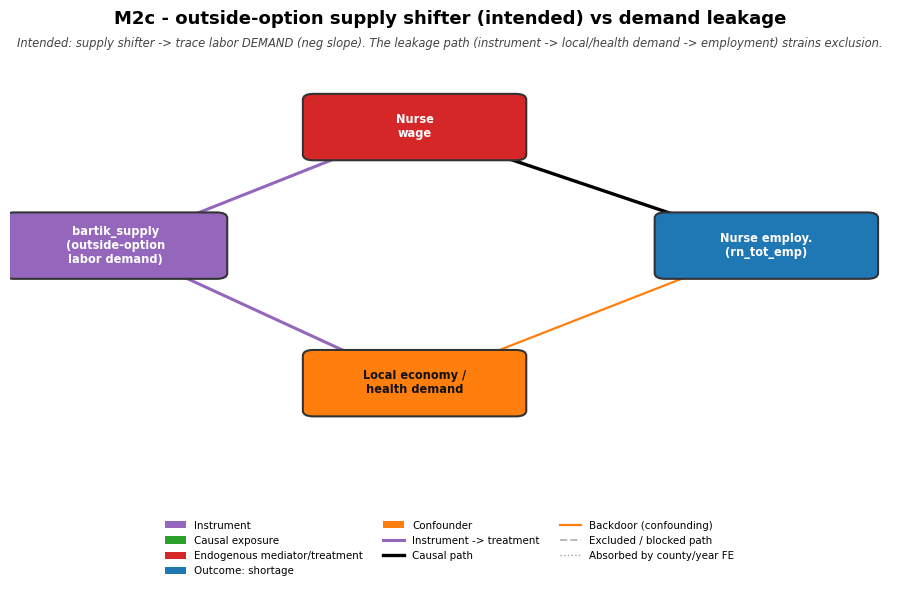

In [10]:
draw_dag(
 {'bartik_supply\n(outside-option\nlabor demand)':(0.12,0.55,'instrument'),
  'Nurse\nwage':(0.46,0.80,'mediator'),
  'Local economy /\nhealth demand':(0.46,0.26,'confounder'),
  'Nurse employ.\n(rn_tot_emp)':(0.86,0.55,'outcome')},
 [('bartik_supply\n(outside-option\nlabor demand)','Nurse\nwage','iv'),
  ('Nurse\nwage','Nurse employ.\n(rn_tot_emp)','causal'),
  ('bartik_supply\n(outside-option\nlabor demand)','Local economy /\nhealth demand','iv'),
  ('Local economy /\nhealth demand','Nurse employ.\n(rn_tot_emp)','backdoor')],
 'M2c - outside-option supply shifter (intended) vs demand leakage',
 'figures/causal_dag_bartik_supply.png',
 note='Intended: supply shifter -> trace labor DEMAND (neg slope). The leakage path (instrument -> local/health demand -> employment) strains exclusion.')

## Limitation: the omitted wage channel

We deliberately **exclude nurse wages** from M0/M1/M3. M2–M2c established there is **no valid instrument** for the local nurse wage (relevance became solvable, exclusion never did), and wage is an **endogenous equilibrium price** — entering it as an ordinary regressor would bias estimates through simultaneity. Given that, omission is the principled choice. What it costs, and what it does *not*:

**Why omission does not bias the included effects.** In the structural DAG, wage is a **mediator** — a demand/supply factor moves wages, which in turn move quantity/shortage — *not* a confounder of our regressors. Omitting a mediator leaves the **total (reduced-form) effect** of each factor intact; it is *controlling* an endogenous mediator that would inject over-control / collider bias. So the M0/M1/M3 coefficients are valid as **total effects** operating through all channels (including any induced wage adjustment) — usually the policy-relevant quantity.

**What we therefore cannot say.**
- No **price-mechanism decomposition** — we cannot split a factor's effect into wage vs non-wage channels.
- No **wage-policy inference** — nothing about pay floors, wage subsidies, or the wage-elasticity of supply/demand.
- No **supply-vs-demand elasticity split** — without the price we observe reduced-form co-movements, not structural curves.

**A threat that remains regardless of the wage decision.** The unobserved **local economy** can still confound the included factors with shortage; county + year FE absorb the time-invariant and common-shock parts but not idiosyncratic local-economic shocks. This is a confounding limitation, separate from — and not fixed by — omitting wage.

**Bottom line.** Excluding wage is correct given no valid instrument. It changes the **estimand** (total reduced-form effects, not price-channel or wage-policy effects), *not* the validity of the reduced-form associations we report.

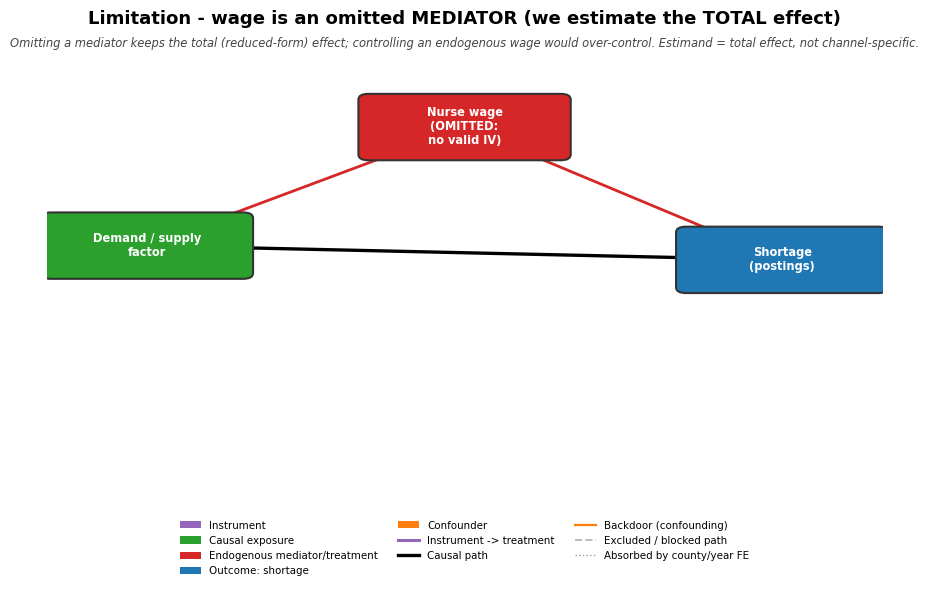

In [11]:
# Wage as an OMITTED MEDIATOR: the black path is the total effect we estimate.
draw_dag(
 {'Demand / supply\nfactor':(0.12,0.55,'exposure'),
  'Nurse wage\n(OMITTED:\nno valid IV)':(0.5,0.80,'mediator'),
  'Shortage\n(postings)':(0.88,0.52,'outcome')},
 [('Demand / supply\nfactor','Shortage\n(postings)','causal'),
  ('Demand / supply\nfactor','Nurse wage\n(OMITTED:\nno valid IV)','mediated'),
  ('Nurse wage\n(OMITTED:\nno valid IV)','Shortage\n(postings)','mediated')],
 'Limitation - wage is an omitted MEDIATOR (we estimate the TOTAL effect)',
 'figures/causal_dag_omitted_wage.png',
 note='Omitting a mediator keeps the total (reduced-form) effect; controlling an endogenous wage would over-control. Estimand = total effect, not channel-specific.')

## M3 — Training-pipeline reduced form (**suggestive, policy-actionable**)

Lagged local **IPEDS completions per 10k** are predetermined relative to current supply, and map directly to a lever policymakers control (program funding, clinical placements). We estimate the reduced-form effect of the lagged pipeline on subsequent **supply** (the mechanism that would relieve shortage).


=== M3 Training pipeline -> supply — RN ===  N=747 counties=83.0 within_R2=0.706
                         coef    se     p
share_65plus            2.747 3.304 0.406
hosp_beds_per_1k        5.532 5.027 0.271
nh_beds_per_65plus_ahrf 0.542 0.313 0.084
poverty_rate            0.560 1.937 0.772
bachelors_plus_share    4.783 2.142 0.026
rn_per_100k_lag1        0.820 0.049 0.000
ipeds_rn_per_10k_lag1   0.118 0.496 0.812

=== M3 Training pipeline -> supply — LPN ===  N=744 counties=83.0 within_R2=0.272
                          coef    se     p
share_65plus            -1.204 8.938 0.893
hosp_beds_per_1k        -3.377 7.401 0.648
nh_beds_per_65plus_ahrf  0.827 0.953 0.386
poverty_rate            -1.317 1.899 0.488
bachelors_plus_share     6.329 3.252 0.052
lpn_per_100k_lag1        0.402 0.163 0.014
ipeds_lpn_per_10k_lag1   2.888 1.011 0.004


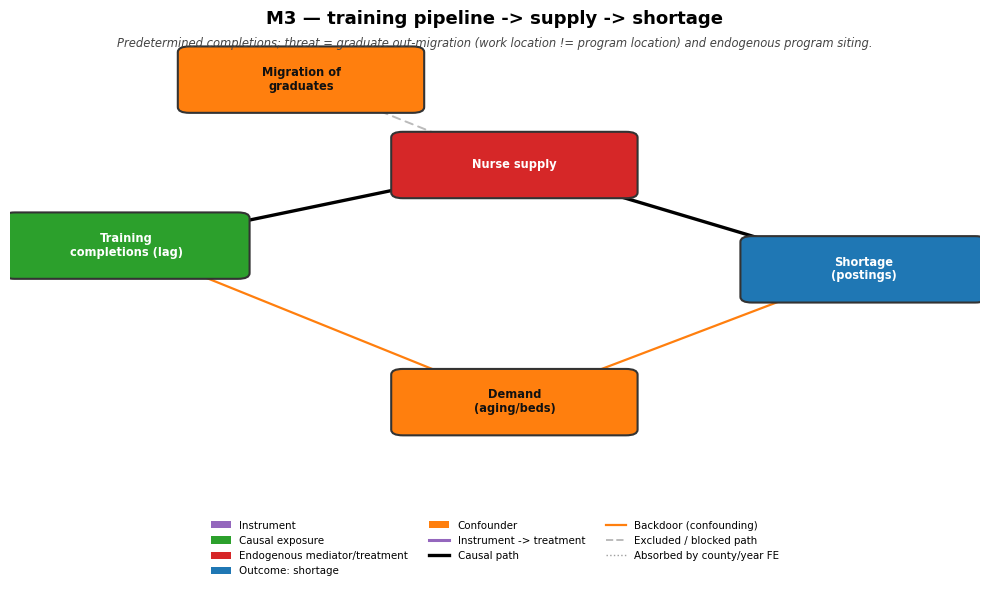

In [15]:
m3={}
for o in ['rn','lpn']:
    y=f'{o}_per_100k'
    xs=DEMAND+[f'{o}_per_100k_lag1', f'ipeds_{o}_per_10k_lag1']
    m3[o]=twfe(y, xs, f'M3 Training pipeline -> supply — {o.upper()}')

draw_dag(
 {'Training\ncompletions (lag)':(0.12,0.55,'exposure'),
  'Nurse supply':(0.52,0.72,'mediator'),
  'Shortage\n(postings)':(0.88,0.50,'outcome'),
  'Demand\n(aging/beds)':(0.52,0.22,'confounder'),
  'Migration of\ngraduates':(0.30,0.90,'confounder')},
 [('Training\ncompletions (lag)','Nurse supply','causal'),
  ('Nurse supply','Shortage\n(postings)','causal'),
  ('Demand\n(aging/beds)','Shortage\n(postings)','backdoor'),
  ('Demand\n(aging/beds)','Training\ncompletions (lag)','backdoor'),
  ('Migration of\ngraduates','Nurse supply','blocked')],
 'M3 — training pipeline -> supply -> shortage',
 'figures/causal_dag_training.png',
 note='Predetermined completions; threat = graduate out-migration (work location != program location) and endogenous program siting.')

## Results summary — strengths, weaknesses, and what each model identifies

In [16]:
summary = pd.DataFrame([
 dict(model='M0 Descriptive TWFE', estimand='within-county association',
      identification='county+year FE only',
      strength='absorbs fixed county & statewide shocks; full sample',
      weakness='simultaneity, reverse causality, time-varying confounders unaddressed',
      interpretability='clear but correlational', causal_credibility='None'),
 dict(model='M1 Predetermined-lag TWFE', estimand='effect of pre-dated factors on later shortage',
      identification='lagged regressors (sequential exogeneity)',
      strength='rules out contemporaneous reverse causation; policy early-warning',
      weakness='predetermined != exogenous; persistent confounders & dynamic feedback remain',
      interpretability='predictive / weak-causal', causal_credibility='Weak'),
 dict(model='M2 Bartik IV (bartik_alt + OEWS)', estimand='causal effect of wages on supply/shortage',
      identification='multi-subsector shift-share for wage, county FE',
      strength='RELEVANCE solved: 3-subsector Bartik + OEWS wage -> first-stage F~37 under county FE',
      weakness='demand shifter -> EXCLUSION fails for wage->supply; absorbed entirely under two-way FE',
      interpretability='strong but invalid for wage->supply; sig. wage->postings is the demand channel',
      causal_credibility='Relevant, not valid'),
 dict(model='M2c Outside-option Bartik (bartik_supply)', estimand='labor demand (supply shifter traces demand)',
      identification='non-health multi-sector shift-share for wage, county FE',
      strength='STRONG: first-stage F~150 under county FE (18 sectors, heterogeneous timing)',
      weakness='wage->employment is POSITIVE (sign flip vs licensed stock) -> residual demand content; F~3 under two-way FE',
      interpretability='strongest instrument yet, but exclusion strained -> no clean elasticity',
      causal_credibility='Strong relevance, exclusion strained'),
 dict(model='M3 Training reduced form', estimand='effect of training pipeline on supply',
      identification='predetermined IPEDS completions',
      strength='predetermined; directly maps to a fundable policy lever',
      weakness='endogenous program siting; graduate out-migration; mediation through supply',
      interpretability='reduced-form policy effect (suggestive)', causal_credibility='Suggestive'),
])
summary.to_csv('outputs/causal_model_summary.csv', index=False)
for _,r in summary.iterrows():
    print(f"\n[{r['model']}]  credibility: {r['causal_credibility']}")
    print(f"  estimand      : {r['estimand']}")
    print(f"  identification: {r['identification']}")
    print(f"  strength      : {r['strength']}")
    print(f"  weakness      : {r['weakness']}")
    print(f"  interpret     : {r['interpretability']}")
print('\nSaved -> outputs/causal_model_summary.csv')


[M0 Descriptive TWFE]  credibility: None
  estimand      : within-county association
  identification: county+year FE only
  strength      : absorbs fixed county & statewide shocks; full sample
  weakness      : simultaneity, reverse causality, time-varying confounders unaddressed
  interpret     : clear but correlational

[M1 Predetermined-lag TWFE]  credibility: Weak
  estimand      : effect of pre-dated factors on later shortage
  identification: lagged regressors (sequential exogeneity)
  strength      : rules out contemporaneous reverse causation; policy early-warning
  weakness      : predetermined != exogenous; persistent confounders & dynamic feedback remain
  interpret     : predictive / weak-causal

[M2 Bartik IV (bartik_alt + OEWS)]  credibility: Relevant, not valid
  estimand      : causal effect of wages on supply/shortage
  identification: multi-subsector shift-share for wage, county FE
  strength      : RELEVANCE solved: 3-subsector Bartik + OEWS wage -> first-stage F~3

## What can and cannot be stated when informing policy

### CAN be stated (supported by these results)
- **Targeting (M0).** Which counties show persistent shortage pressure conditional on observed demand factors — a defensible basis for *where* to direct attention. Descriptive, but transparent and reproducible.
- **Early-warning predictors (M1).** Pre-dated conditions (last year's low supply, thin pipeline, older workforce) that *predict* higher subsequent shortage. Useful for forecasting/prioritization, stated as prediction not effect.
- **Pipeline relevance (M3).** Local training output is **positively and predeterminedly associated** with later local supply, especially for LPNs. Framed as: *expanding local LPN training is consistent with raising local LPN supply* — a policy-actionable, suggestive (not clean-causal) result.

### CANNOT be stated (not supported)
- **No causal "effect of X on shortage" from M0/M1.** Sequential exogeneity is not exogeneity; unobserved local-economy confounding remains. Do not write "raising wages would reduce shortage by ..." from these.
- **No causal wage->supply claim.** The rebuilt multi-subsector instrument (`bartik_alt`) with OEWS wages is now *strong* (first-stage F~37 under county FE), but it is a **labor-demand** shifter and therefore **violates the exclusion restriction** for a wage effect (it moves postings directly through demand). The significant wage->postings estimate is the demand channel, not a causal wage effect; under two-way FE the instrument is absorbed. So no causal wage->supply statement is supported — relevance was solved, validity was not.
- **The outside-option instrument (`bartik_supply`) is the strongest we built** (first-stage F~150 under county FE) and is a labor-*supply* shifter — but `wage->employment` comes out *positive*, the opposite of the downward-sloping demand a clean supply shifter implies. That sign flip shows it still carries local-demand content, so even this instrument does not deliver a clean causal elasticity. The design-robust statement is descriptive: **tighter nurse labor supply co-moves with higher shortage (postings)** across all specifications.
- **No causal magnitude for the training lever.** M3 is reduced-form and threatened by program-siting endogeneity and graduate out-migration (program location != work location). It motivates, but does not prove, that funding programs *causes* supply gains.
- **Nothing about magnet hospitals or MSA-level levers.** Dropped earlier: sparse, MSA-aggregated, near-zero within-county identifying variation.
- **No claims about patient outcomes or care quality.** Not measured in this panel.

### What would be needed for stronger causal claims
- A **strong, defensible instrument** with within-county-over-time variation (e.g., multiple industry-level shocks for a proper many-shock Bartik, or a policy discontinuity).
- **Staggered policy events** (program openings, scholarship/loan-repayment rollouts) for event-study / difference-in-differences.
- **Workplace-based** nurse location (vs residence) and **realized hires** (vs postings) to sharpen the shortage measure.